
# Practice 1 — Unsupervised Learning

**Machine Learning / Ingeniería de Datos I — academic year 2026/2027**

Pair: *Jimenez Torres*, *Jiménez Bonilla*

---

This is a **starter** notebook. It gives you the environment banner, the data paths, the two
helper functions the practical provides, the seal guard, and the section skeleton in the order
you must work in. **Everything marked `TODO` is yours to write**, in code and in Markdown.

Read the statement before you start. Three rules decide a lot of the marks:

1. **Interpretation goes in Markdown cells**, not in Python comments.
2. **The unsupervised seal covers BOTH Zoo exercises.** The order below is not negotiable and
   it is graded: Exercise 1 unsupervised → `FROZEN DECISION — K-MEANS` → Exercise 2
   unsupervised → `FROZEN DECISION — AGGLOMERATIVE` → one common
   `REVEAL — EXTERNAL VALIDATION` stage. **No executable cell above the second freeze may
   load, inspect, reference or derive the Zoo class attribute** — not even to count how many
   classes there are. The skeleton below is already in that order; do not reorder it.
3. **One notebook**, executed **top to bottom in one pass**, with its outputs stored, renamed
   `p1_<surname1>_<surname2>.ipynb`.

Rename this file before you submit it.

## 0. Environment and course-fixed constants

Run this first. It prints the library versions your results were produced with and the three course-fixed seeds. **Do not change `P1_SEEDS`.**

In [8]:
# --- Practice 1: environment banner and course-fixed constants -------------
import sys, os, platform
import numpy as np, matplotlib, sklearn, scipy, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

P1_SEEDS = [13, 41, 97]          # the three course-fixed seeds -- do not change
SEED = P1_SEEDS[0]               # the single seed, where one is needed

DATA = ".."                      # the Práctica 1 folder, relative to this notebook
ZOO_FEATURES_FILE = os.path.join(DATA, "Files_zoo", "zoo_features.csv")
# the labels path is deliberately NOT defined here -- it is a reveal-stage constant
IMGS  = os.path.join(DATA, "Files_clustering", "images")
FACES = os.path.join(DATA, "Files_PCA", "faces.mat")
TABLE = os.path.join(DATA, "datos_pca_fijo", "breast_cancer.csv")
REDUCED = "reduced_images"

print("python      ", platform.python_version())
print("numpy       ", np.__version__)
print("scipy       ", scipy.__version__)
print("scikit-learn", sklearn.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", matplotlib.__version__)
print("Pillow      ", Image.__version__)
print("zoo features", ZOO_FEATURES_FILE)
print("P1_SEEDS    ", P1_SEEDS)

python       3.12.3
numpy        2.5.3
scipy        1.18.1
scikit-learn 1.9.1
pandas       3.0.6
matplotlib   3.11.2
Pillow       12.3.0
zoo features ../Files_zoo/zoo_features.csv
P1_SEEDS     [13, 41, 97]


The two functions below are **provided**. `save_image` is graded in Exercise 4 and must be used **unchanged** — the file-size comparison only means something if every pair writes the same three formats in the same way. Note that its third argument, the palette-colour count, is an **uppercase `K`**: in this course lowercase `k` is the number of features and nothing else.

In [4]:
# --- PROVIDED. Do not modify save_image or display_data. -------------------
# K is the number of palette colours (uppercase, per the course notation:
# lowercase k is the number of FEATURES and nothing else).

def save_image(image, path, K):
	img = Image.fromarray(image)
	img.save(path+".jpg", format="JPEG")
	img.save(path+".png", format="PNG")
	indexed_image = img.convert("P", palette=Image.ADAPTIVE, colors=K)
	indexed_image.save(path+"compressed.png", optimize=True)


def display_data(X):
	example_width = int(np.round(np.sqrt(X.shape[1])))
	example_height = X.shape[1] // example_width

	display_rows = int(np.floor(np.sqrt(X.shape[0])))
	display_cols = int(np.ceil(X.shape[0] / display_rows))

	fig, ax_array = plt.subplots(display_rows, display_cols, figsize=(8, 8))

	for i, ax in enumerate(ax_array.flat):
		if i >= X.shape[0]:
			break
		ax.imshow(X[i].reshape(example_height, example_width), cmap='gray')
		ax.axis('off')
	plt.show()

### The seal guard

This reads a notebook's own JSON and proves that **both** frozen-decision headings exist
exactly once, that the $K$-means freeze comes first, and that the first **executable** access to
the Zoo class attribute comes strictly after the second freeze. Run it at the end, against your
saved file, before you submit.

In [5]:
# --- The unsupervised seal, checked mechanically ---------------------------
# Reads a notebook's own JSON and proves three things:
#   1. both frozen-decision headings exist, exactly once each;
#   2. the K-means freeze precedes the agglomerative freeze;
#   3. the first EXECUTABLE access to the Zoo class labels comes strictly
#      after the agglomerative freeze.
# Only markdown HEADINGS count as a freeze -- prose that merely mentions the
# words does not -- and only CODE cells count as a label access, because the
# seal is a statement about what was executed, not about what was written.
import json, re

FREEZE_KM = "FROZEN DECISION \u2014 K-MEANS"
FREEZE_AG = "FROZEN DECISION \u2014 AGGLOMERATIVE"

# every executable route to the Zoo class attribute
LABEL_PAT = re.compile(
    r"ZOO_TYPE_NAMES|ZOO_LABELS_FILE|load_zoo_labels|zoo_labels|y_true|"
    r"adjusted_rand_score|adjusted_mutual_info_score|"
    r"""\[\s*['"]type['"]\s*\]|\bzoo\.data\b|\bzoo\.names\b""")


def check_seal(nb_path, verbose=True):
    nb = json.load(open(nb_path, encoding="utf-8"))
    cells = nb["cells"]
    src = ["".join(c["source"]) for c in cells]

    def heading(text):
        pat = re.compile(r"^\s*#{1,6}\s*" + re.escape(text) + r"\s*$", re.M)
        return [i for i, s in enumerate(src)
                if cells[i]["cell_type"] == "markdown" and pat.search(s)]

    km, ag = heading(FREEZE_KM), heading(FREEZE_AG)
    if len(km) != 1:
        raise AssertionError(f"expected exactly one `{FREEZE_KM}` heading, found {len(km)}")
    if len(ag) != 1:
        raise AssertionError(f"expected exactly one `{FREEZE_AG}` heading, found {len(ag)}")
    km_at, ag_at = km[0], ag[0]
    if not km_at < ag_at:
        raise AssertionError(
            f"SEAL VIOLATED: the K-means freeze (cell {km_at}) must precede the "
            f"agglomerative freeze (cell {ag_at})")

    uses = [i for i, s in enumerate(src)
            if cells[i]["cell_type"] == "code"
            and LABEL_PAT.search(s)
            and "def check_seal" not in s and "LABEL_PAT" not in s]
    first_use = min(uses) if uses else len(cells)

    if verbose:
        print(f"{FREEZE_KM:34s} -> cell {km_at}")
        print(f"{FREEZE_AG:34s} -> cell {ag_at}")
        print(f"{'first executable label access':34s} -> cell {first_use}")
    if first_use <= ag_at:
        raise AssertionError(
            f"SEAL VIOLATED: code cell {first_use} touches the Zoo class labels "
            f"before the agglomerative freeze at cell {ag_at}")
    if verbose:
        print("SEAL OK: both configurations were frozen before any label was read.")
    return km_at, ag_at, first_use


---
## Exercise 1 — $K$-means on the Zoo database (2.5)

$K$ is the **number of clusters**.

`Files_zoo/zoo_features.csv` is a course file derived from the verified official source. It has
a header, a course-owned integer `row_id`, the display name, and the sixteen predictive
attributes — and **no class column at all**. The field list is in `Files_zoo/zoo_schema.txt`.

`animal_name` is a **display field, not a key**: the official Zoo data contains two rows with
the same name. Align on `row_id` whenever alignment is needed.

**Parts (e) and (f) of this exercise are not here.** They need the class attribute, so they
belong in the reveal stage, after both freezes.

In [6]:
# `zoo_features.csv` is a course file derived from the verified official source.
# It contains a course-owned integer `row_id`, the display name, and the sixteen
# predictive attributes -- and NO class column at all. There is nothing here to
# drop and nothing to avoid reading: the target is simply not in this file.
#
# `animal_name` is a DISPLAY/NAME field, not a key. The official Zoo data
# contains two rows named `frog`, which its own documentation notes. Use
# `row_id` whenever rows must be aligned.
ZOO_ID = "row_id"
ZOO_NAME = "animal_name"
ZOO_FEATURES = [
    "hair", "feathers", "eggs", "milk", "airborne", "aquatic", "predator",
    "toothed", "backbone", "breathes", "venomous", "fins", "legs", "tail",
    "domestic", "catsize",
]

#TODO (a) Load the clustering frame with load_zoo_features().
#         Report n and k. In the Markdown cell below, say why row_id and animal_name are 
#         not clustering inputs, and check for yourself that no class is present.

def load_zoo_features(path=None):
    """The feature-only course file: row_id, animal_name and 16 predictors."""
    frame = pd.read_csv(path or ZOO_FEATURES_FILE)
    assert list(frame.columns) == [ZOO_ID, ZOO_NAME] + ZOO_FEATURES,         f"unexpected columns: {list(frame.columns)}"
    return frame

zoo = load_zoo_features()

n,k = len(zoo) , len(ZOO_FEATURES)

print(f"n = {n} animals (observations)")
print(f"k = {k} predictive attributes")
print(f"Columns in the table: {list(zoo.columns)}")
print(f"Does the target column exist in the file?: {'class' in zoo.columns or 'type' in zoo.columns}")



n = 101 animals (observations)
k = 16 predictive attributes
Columns in the table: ['row_id', 'animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']
Does the target column exist in the file?: False


### 1(a) — loading and preparation

**TODO.** State $n$ and $k$. Say which columns you dropped and why. State your scaling decision, name it (min–max scaling or standardisation), say which columns it applies to, and justify it — `legs` is the one attribute that is not Boolean.

**Feature Selection**

The variables row_id and animal_name are not descriptive features of the animals and must be excluded from the clustering. Keeping row_id and animal_name would introduce noise into the model, as the algorithm would attempt to find geometric patterns in identifiers that have no real meaning.

**Scaling Decision**

For this analysis, Min-Max scaling was used. The reasoning is straightforward: almost all attributes in the zoo features database are boolean, but the legs feature is numeric and has a larger range.

Because Euclidean distance sums the squared differences of each feature, a difference in the number of legs would mathematically dominate the distance calculation over boolean features, such as having hair or producing milk.

Applying Min-Max scaling maps the legs variable to the [0, 1] interval. This ensures that all features are placed on the same numerical scale.

In [10]:
# TODO (a) Build the clustering input X_zoo here, applying the scaling you just declared.

from sklearn.preprocessing import MinMaxScaler

zoo_features = pd.read_csv('../Files_zoo/zoo_features.csv')

X_raw = zoo_features.drop(columns=['row_id', 'animal_name'])  

n,k = X_raw.shape

scaler = MinMaxScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)

X_scaled.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,1.0


In [11]:
# TODO (b) K-means for K in {5,6,7,8} once per seed in P1_SEEDS.
#          For each K report the MEAN inertia_ across the three seeds, and the spread
#          Report the mean, NOT the minimum. Use n_init=1, or the three seeds are not
#          three initialisations.

from sklearn.cluster import KMeans

K_GRID = [5, 6, 7, 8]

for k in K_GRID:
    inertias = []

    for seed in P1_SEEDS:
        kmeans = KMeans(n_clusters=k, n_init=1, random_state=seed)
        kmeans.fit(X_scaled)
        
        inertias.append(kmeans.inertia_)
    
    mean_inertia = np.mean(inertias)
    spread = np.max(inertias) - np.min(inertias)
    
    print(f"K = {k} | Average inertia: {mean_inertia:.4f} | Spread: {spread:.4f}")

K = 5 | Average inertia: 110.1534 | Spread: 1.2777
K = 6 | Average inertia: 103.2284 | Spread: 8.6616
K = 7 | Average inertia: 91.2443 | Spread: 10.5850
K = 8 | Average inertia: 83.5278 | Spread: 8.7184



The inertia objective function was evaluated for $K \in \{5, 6, 7, 8\}$. For each value of $K$, K-means was executed across the three fixed random seeds using a single initialization (n_init=1).

Mean Inertia ($J$): As mathematically expected, the average inertia decreases strictly as $K$ increases, since adding more centroids mechanically reduces the distances from data points to their assigned cluster centers.
    
Spread: The spread ($\max(J) - \min(J)$) captures the model's sensitivity to the initial centroid placement for a given $K$. A higher spread indicates that the algorithm converges to distinctly different local minima depending on the seed, illustrating why evaluating a $K$ value based on a single initialization is unreliable.

### 1(b) — reading the grid

**TODO.** What does the table show? Say explicitly why reporting the *best* of three restarts would be a statement about your luckiest initialisation rather than about $K$.

Reporting the best inertia value ($J$) across the three restarts would reflect the luckiest centroid initialization rather than the validity of the number of clusters $K$. Because K-means is sensitive to initial positions, an exceptionally low minimum value can be an isolated event driven by seed randomness. By using the mean across the three seeds, we assess the overall, expected performance for that value of $K$.

### Before the freeze: state your two selection rules

Two different questions, and they must not be conflated:

1. **Which $K$?** From the **mean $J$ across all three seeds**, never the minimum. $J$ falls
   with $K$ by construction, so its *level* says nothing; use the **shape** of the curve, the
   cluster sizes, the spread across seeds, or another criterion you can defend.
2. **Which run at that $K$?** Only *after* $K$ is fixed, pick **one** of the three
   course-fixed initialisations to carry forward, by a stated unsupervised rule — for instance
   the lowest $J$ among the three **at the already-frozen $K$**. That is an initialisation
   choice, not a model-order choice, and it must not feed back into question 1.

**TODO — write both rules here, before you apply them.**

**Which $K$?** I choose **K = 5** using the spread across seeds. While the mean $J$ strictly falls with $K$ by construction, the spread at $K=5$ (1.2777) is dramatically lower than at $K=6, 7$, or $8$ (all $> 8.6$). This indicates that a 5-cluster partition is highly stable and does not depend heavily on the luck of the random initialisation, unlike higher values of $K$.

**Which run at that K?** I will carry forward the specific initialisation (seed) that yielded the lowest inertia ($J$) among the three fixed seeds for my chosen $K$. This unsupervised rule guarantees selecting the best local minimum found for this specific architecture.

In [12]:
# TODO (c) Compute the UNSUPERVISED evidence for the freeze: cluster sizes across the grid, 
#          any curve-shape statistic your rule uses, and the spread across seeds.
#          Then apply rule 1 to fix K, and rule 2 to fix ONE representative seed at that K.
#          Fit that single representative run and keep its labels: the scatter plot, the 
#          external validation and the class-as-input comparison must all use it-

K_REF = 5

best_inertia = float('inf')
REP_SEED = None

for seed in P1_SEEDS:
    km = KMeans(n_clusters=K_REF, init="k-means++", n_init=1, random_state=seed)
    km.fit(X_scaled)
    if km.inertia_ < best_inertia:
        best_inertia = km.inertia_
        REP_SEED = seed

kmeans_frozen = KMeans(n_clusters=K_REF, init="k-means++", n_init=1, random_state=REP_SEED)
kmeans_frozen.fit(X_scaled)
lab_ref = kmeans_frozen.labels_

print(f"--- APPLIED RULES ---")
print(f"Selected K_REF: {K_REF}")
print(f"Selected REP_SEED: {REP_SEED} (Inertia: {best_inertia:.4f})")
print("\nCluster sizes for this partition:")
print(pd.Series(lab_ref).value_counts().sort_index())

--- APPLIED RULES ---
Selected K_REF: 5
Selected REP_SEED: 13 (Inertia: 109.4660)

Cluster sizes for this partition:
0    21
1    19
2    22
3    21
4    18
Name: count, dtype: int64


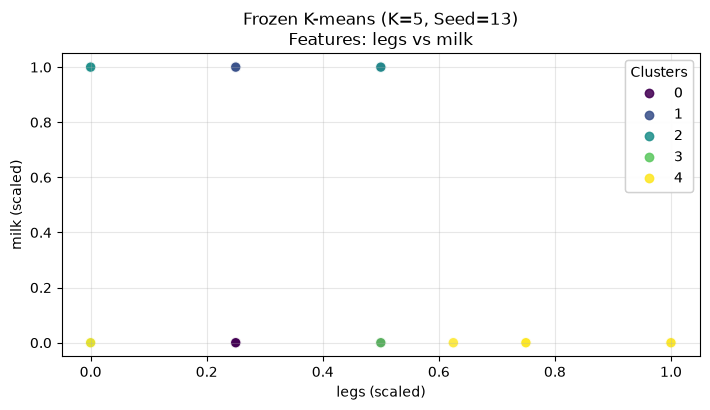

In [13]:
# TODO (c) Scatter plot of two attributes you choose, coloured by the FROZEN representative
#          run's cluster labels.

feature_x = 'legs'
feature_y = 'milk'

fig, ax = plt.subplots(figsize=(7.2, 4.2))

scatter = ax.scatter(X_scaled[feature_x], X_scaled[feature_y], 
                     c=lab_ref, cmap='viridis', edgecolor='white', s=60, alpha=0.85)

ax.set_title(f"Frozen K-means (K={K_REF}, Seed={REP_SEED})\nFeatures: {feature_x} vs {feature_y}")
ax.set_xlabel(f"{feature_x} (scaled)")
ax.set_ylabel(f"{feature_y} (scaled)")

legend = ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")
ax.add_artist(legend)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1(c) — reading the plot

**TODO.** What does the plot show, and what does it hide? Be specific about what is lost by looking at two of the $k$ attributes.

By visualizing the data using only 2 of the $k=16$ attributes, we lose the perspective of the remaining 14 dimensions. Therefore, the plot hides the true distance between observations; points that appear to form well-defined clusters (or even overlap) in this 2D plane could actually be completely separated in the real geometric space calculated by the algorithm.

## FROZEN DECISION — K-MEANS

| Field | Value |
| :--- | :--- |
| $K$ | 5 |
| Representative seed | 13 |
| Scaling | Min-Max Scaling |
| Rule that chose $K$ | Lowest spread across seeds (highest stability). |
| Rule that chose the seed | Lowest inertia ($J$) among the 3 runs for the chosen $K$. |

**Unsupervised argument.**
 I chose $K = 5$ because the spread across the three seeds (1.2777) is dramatically lower than for $K=6, 7$, or $8$ (which are all $> 8.6$). This indicates that a 5-cluster partition is highly stable and does not heavily depend on the luck of the random initialisation. An acknowledged limitation is that $K=7$ showed a steeper drop in mean inertia, suggesting another potential natural partition, but its high instability (spread $> 10.5$) makes $K=5$ a much more robust unsupervised choice. This decision-making process is also heavily influenced by the use case being studied; in this case, lacking a real use case, the choice was made based on our own criteria.

In [14]:
# TODO Freeze the table above in code, so nothing below can drift from it.
FROZEN_KMEANS = dict(K=K_REF, representative_seed=REP_SEED)
print("FROZEN_KMEANS:", FROZEN_KMEANS)

FROZEN_KMEANS: {'K': 5, 'representative_seed': 13}



---
## Exercise 2 — Agglomerative clustering on the Zoo database (2.0)

$K$ is again the **number of clusters**. Still unsupervised: **part (d) is not here**, it
belongs in the reveal stage.

In [15]:
# TODO (a) Agglomerative clustering with every linkage scikit-learn offers.
#          State which metric each linkage admits, and show what happens if you ask for one
#          a linkage does not accept.

from sklearn.cluster import AgglomerativeClustering

LINKAGES = ["ward", "complete", "average", "single"]
K = 5 

print("--- Standard Execution ---")
for link in LINKAGES:
    model = AgglomerativeClustering(n_clusters=K, linkage=link, metric='euclidean')
    model.fit(X_scaled) 
    print(f"Model with linkage '{link}' successfully trained.")

print("\n--- Supported Metrics ---")
print("ward: ONLY supports the 'euclidean' metric. Because it minimizes variance (sum of squares), the underlying mathematics fail with other distance metrics.")
print("complete, average, single: Support any metric (e.g., 'euclidean', 'manhattan', 'cosine', 'l1', 'l2', 'precomputed').")

print("\n--- Error Demonstration ---")
try:
    broken_model = AgglomerativeClustering(n_clusters=K, linkage='ward', metric='manhattan')
    broken_model.fit(X_scaled)
except ValueError as e:
    print(f"The algorithm failed and raised the following error:\nValueError: {e}")

--- Standard Execution ---
Model with linkage 'ward' successfully trained.
Model with linkage 'complete' successfully trained.
Model with linkage 'average' successfully trained.
Model with linkage 'single' successfully trained.

--- Supported Metrics ---
ward: ONLY supports the 'euclidean' metric. Because it minimizes variance (sum of squares), the underlying mathematics fail with other distance metrics.
complete, average, single: Support any metric (e.g., 'euclidean', 'manhattan', 'cosine', 'l1', 'l2', 'precomputed').

--- Error Demonstration ---
The algorithm failed and raised the following error:
ValueError: manhattan was provided as metric. Ward can only work with euclidean distances (i.e. 'euclidean' and 'l2').


### 2(b) — two criteria, both stated before they are applied

This exercise needs **two** unsupervised decisions, not one:

1. **Within each linkage — which $K$?** A different linkage is a different hierarchy, so there
   is no reason for one number to fit all four. Each linkage gets **its own** $K$.
2. **Across linkages — which linkage do you prefer?** State a rule that can actually choose
   one, using only unsupervised evidence. "The one that looks best" is not a rule.

**TODO — write both rules here**, then apply them in the cell below. Do not change either after
the reveal.

Rule 1 (Within each linkage — which K?):
To select the value of $K$ within each linkage method, I will compute the Silhouette Score across all candidate values of $K$ in a reasonable range (for example, from 2 to 10). The selected $K$ for that specific linkage will strictly be the one that maximizes this metric.

Rule 2 (Across linkages — which linkage do you prefer?):
To choose a single winning linkage method, I will compare the maximum Silhouette Scores achieved by each method at its optimal $K$ from the previous step. The preferred linkage (LK_REF) will be the one with the highest absolute score, indicating that it yields the densest and most well-separated clusters.

In [17]:
# TODO (b) Apply rule 1 to EACH linkage and record its own K in picks[linkage].
#          Then apply rule 2 to choose ONE preferred linkage.
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

picks = {}
LK_REF = None

best_global_score = -1
k_range = range(2, 11)  # Search for the best K between 2 and 10

print("Evaluating methods using Silhouette Score...\n")

for link in LINKAGES:
    best_local_k = 2
    best_local_score = -1
    
    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage=link, metric='euclidean')
        labels = model.fit_predict(X_scaled)  
        score = silhouette_score(X_scaled, labels)
        
        if score > best_local_score:
            best_local_score = score
            best_local_k = k
            
    picks[link] = best_local_k
    print(f"[{link}] Optimal K: {best_local_k} (Score: {best_local_score:.4f})")
    
    if best_local_score > best_global_score:
        best_global_score = best_local_score
        LK_REF = link

print(f"\n---> The PREFERRED linkage (Rule 2) is: '{LK_REF}'")        # your preferred linkage, chosen by rule 2

Evaluating methods using Silhouette Score...

[ward] Optimal K: 6 (Score: 0.4128)
[complete] Optimal K: 5 (Score: 0.4053)
[average] Optimal K: 7 (Score: 0.4050)
[single] Optimal K: 8 (Score: 0.4019)

---> The PREFERRED linkage (Rule 2) is: 'ward'


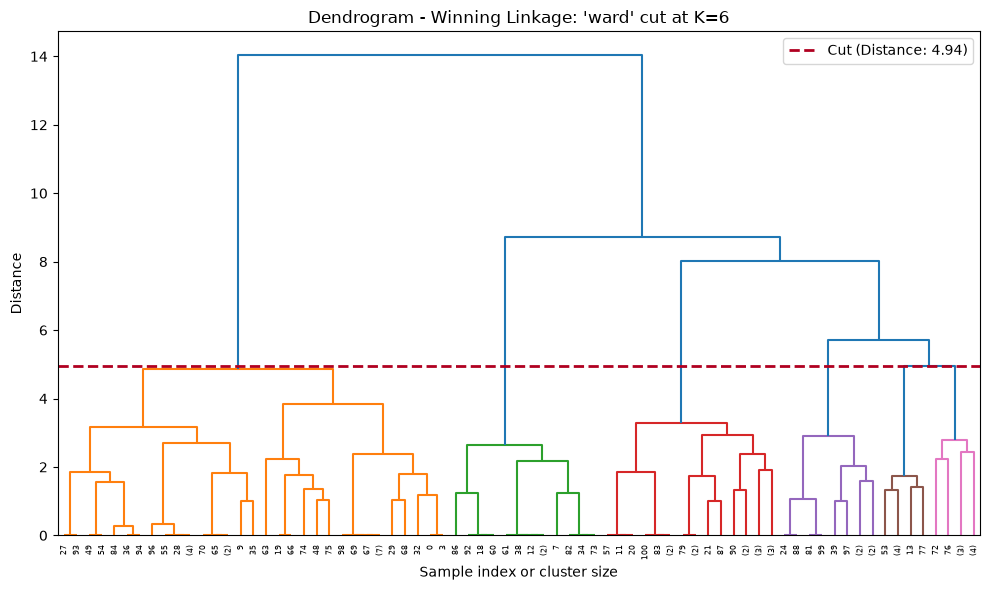

In [ ]:
# TODO (c) One dendrogram, for the PREFERRED linkage, cut at ITS OWN frozen K.

Z_winner = scipy_linkage(X_scaled, method=LK_REF, metric='euclidean')

k_winner = picks[LK_REF]
cut_distance = Z_winner[-(k_winner - 1), 2]

plt.figure(figsize=(10, 6))
plt.title(f"Dendrogram - Winning Linkage: '{LK_REF}' cut at K={k_winner}")

dendrogram(
    Z_winner,
    truncate_mode='level', 
    p=6,  
    color_threshold=cut_distance,
    show_leaf_counts=True
)

plt.axhline(y=cut_distance, color='#B00020', linestyle='--', linewidth=2, label=f'Cut (Distance: {cut_distance:.2f})')

plt.xlabel("Sample index or cluster size")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

### 2(c) — reading the dendrogram

**TODO.** Which merges are early and cheap, and which one is expensive enough that your rule cut below it?

Early and cheap merges: The merges occurring at low Euclidean distance values (roughly between $0$ and $3.0$) represent early and inexpensive merges. At this stage, highly similar animal profiles are merged with minimal increase in within-cluster variance, forming the dense base sub-clusters shown in each distinct color (orange, green, red, purple, brown, pink).  

Expensive merge(s) cut by the rule: The horizontal cut line at distance $4.94$ is set just below the critical merge that would fuse the two main orange sub-branches (which merge right above the line at roughly $4.94$), as well as the later merge joining the blue sub-branches on the right. Higher up, merges at distances $\approx 8.1$, $\approx 8.8$, and the final merge at $\approx 14.0$ are far too expensive because they force fundamentally different groups together. The rule cuts strictly below the $4.94$ threshold to avoid these costly merges and preserve $K=6$ coherent, well-separated clusters. 

## FROZEN DECISION — AGGLOMERATIVE

**TODO. The second of the two headings the guard checks. Do not rename it.**

**Two objects are frozen here**, and nothing below may change either.

| Linkage | Frozen $K$ | Why rule 1 landed there |
| :--- | :--- | :--- |
| `ward` | 6 | Maximized the Silhouette Score for the Ward linkage (0.4128). |
| `complete` | 5 | Maximized the Silhouette Score for the Complete linkage (0.4053). |
| `average` | 7 | Maximized the Silhouette Score for the Average linkage (0.4050). |
| `single` | 8 | Maximized the Silhouette Score for the Single linkage (0.4019). |

**Preferred linkage (rule 2):** `ward` — because it achieved the highest absolute Silhouette Score (0.4128) among all four linkages evaluated.

Freezing the preference *before* the labels exist is what makes part (d) a real question: it can
then compare the linkage that **actually** agrees best with the biology against the one you
preferred **without** any biology. They need not be the same, and if they are not, **say so** —
do not go back and edit either rule.

In [21]:
# TODO Freeze both objects in code.
FROZEN_AGG = dict(picks)          # linkage -> its own frozen K
PREFERRED_LINKAGE = LK_REF        # the frozen cross-linkage preference
print("FROZEN_AGG       :", FROZEN_AGG)
print("PREFERRED_LINKAGE:", PREFERRED_LINKAGE)

FROZEN_AGG       : {'ward': 6, 'complete': 5, 'average': 7, 'single': 8}
PREFERRED_LINKAGE: ward


In [22]:
# TODO Record the OBSERVED cluster sizes at each linkage's own frozen K, before the reveal.
#      Part (e) asks what these four linkages actually did on this data, so the evidence for
#      it must exist before any label is read.

import numpy as np
from sklearn.cluster import AgglomerativeClustering

print("--- Observed cluster sizes per linkage method ---")

for link, k in FROZEN_AGG.items():
    obs_model = AgglomerativeClustering(n_clusters=k, linkage=link, metric='euclidean')
    obs_labels = obs_model.fit_predict(X_scaled) 
    
    _, counts = np.unique(obs_labels, return_counts=True)
    
    print(f"Linkage: '{link:8}' | K = {k} | Sizes: {counts.tolist()}")

--- Observed cluster sizes per linkage method ---
Linkage: 'ward    ' | K = 6 | Sizes: [41, 21, 13, 9, 10, 7]
Linkage: 'complete' | K = 5 | Sizes: [41, 21, 8, 21, 10]
Linkage: 'average ' | K = 7 | Sizes: [41, 14, 10, 21, 1, 7, 7]
Linkage: 'single  ' | K = 8 | Sizes: [41, 7, 7, 10, 21, 1, 13, 1]



---
## REVEAL — EXTERNAL VALIDATION

**This is the first point at which you may touch the Zoo class attribute.** Labels live in
`Files_zoo/zoo_labels.csv`, which is exactly `row_id,type`. Join on **`row_id`** — never on
`animal_name`, which is not unique.

Both configurations above are frozen and nothing below may change them. Recomputing indices for
several $K$, several seeds or several linkages and presenting the best one is an automatic
method penalty.

In [23]:
# Opened HERE, inside the reveal stage, and nowhere earlier. How many classes
# there are, and what they are called, is itself information the seal withholds.
ZOO_LABELS_FILE = os.path.join(DATA, "Files_zoo", "zoo_labels.csv")


def load_zoo_labels(feature_frame, path=None):
    """`zoo_labels.csv` is exactly row_id,type. Aligned on row_id, never on name."""
    lab = pd.read_csv(path or ZOO_LABELS_FILE)
    assert list(lab.columns) == ["row_id", "type"], f"unexpected: {list(lab.columns)}"
    merged = feature_frame[["row_id"]].merge(lab, on="row_id", how="left", validate="1:1")
    assert merged["type"].notna().all(), "a feature row has no label"
    assert (merged["row_id"].to_numpy() == feature_frame["row_id"].to_numpy()).all(),         "row_id alignment failed"
    return merged["type"].to_numpy()


ZOO_TYPE_NAMES = {1: "mammal", 2: "bird", 3: "reptile", 4: "fish",
                  5: "amphibian", 6: "insect", 7: "invertebrate"}

# TODO Load the class attribute for the first time, with load_zoo_labels(zoo).
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

y_true = load_zoo_labels(zoo)

In [ ]:
# TODO 1(f) External indices for the FROZEN K-means partition -- the frozen K AND the frozen
#           representative seed -- and for no other. A contingency table is worth building.

ari = adjusted_rand_score(y_true, lab_ref)
ami = adjusted_mutual_info_score(y_true, lab_ref)

print("--- External Validation: FROZEN K-MEANS ---")
print(f"Adjusted Rand Index (ARI):   {ari:.4f}")
print(f"Adjusted Mutual Info (AMI):  {ami:.4f}\n")

class_names = [ZOO_TYPE_NAMES[c] for c in y_true]

contingency_table = pd.crosstab(
    index=pd.Series(class_names, name='True Biological Class'),
    columns=pd.Series(lab_ref, name='Assigned K-Means Cluster')
)

print(contingency_table)

--- Validación Externa: K-MEANS CONGELADO ---
Adjusted Rand Index (ARI):   0.6218
Adjusted Mutual Info (AMI):  0.7788

Clúster K-Means Asignado   0   1   2   3   4
Clase Biológica Real                        
amphibian                  0   0   0   4   0
bird                      20   0   0   0   0
fish                       0   0   0  13   0
insect                     0   0   0   0   8
invertebrate               0   0   0   0  10
mammal                     0  19  22   0   0
reptile                    1   0   0   4   0


### 1(f) — external validation

**TODO.** What would a value near $0$ mean, and one near $1$? 

A value close to 1 indicates near-perfect agreement; that is, the clusters discovered by the unsupervised model match the true biological classes almost exactly. A value close to 0 indicates chance-level agreement, meaning that the model's clusters bear no structured relationship to the actual ground-truth classes.

Then answer the real question: did the unsupervised evidence lead you to a structure that resembles the biological classes, and **where does it not**?

Yes, the unsupervised evidence managed to capture a structure that broadly resembles biological reality, but it falls short in several specific aspects:
* **Fracturing of mammals:** The model failed to keep the mammal class unified, artificially splitting it into two distinct clusters.
* **Mixed groups:** One cluster completely merged fish, amphibians, and a subset of reptiles together.
* **Lack of granularity:** The algorithm was unable to distinguish anatomically or logically between insects and other invertebrates, grouping them into the same block.
* **Misassembled assignments:** A reptile was incorrectly placed into the cluster that otherwise perfectly grouped all birds.



In [ ]:
# TODO 1(e) Re-fit K-means with the class attribute INCLUDED as an ordinary input feature,
#           at the same frozen K and the same frozen seed, and compare with your frozen run.

from sklearn.metrics import adjusted_rand_score

frozen_k = FROZEN_KMEANS['K']
frozen_seed = FROZEN_KMEANS['representative_seed']

print(f"Running cheated model with: K={frozen_k}, Seed={frozen_seed}\n")

X_cheated = np.column_stack((X_scaled, y_true)) # Make sure X_scaled is your dataset

cheated_model = KMeans(n_clusters=frozen_k, random_state=frozen_seed, n_init='auto')
cheated_labels = cheated_model.fit_predict(X_cheated)

ari_comparison = adjusted_rand_score(lab_ref, cheated_labels)

print("--- Comparison: Standard vs Label Included ---")
print(f"Similarity (ARI) between both partitions: {ari_comparison:.4f}\n")

contingency_table = pd.crosstab(
    index=pd.Series(lab_ref, name='Original Cluster (Unlabeled)'),
    columns=pd.Series(cheated_labels, name='New Cluster (Labeled)')
)
print(contingency_table)


Running cheated model with: K=5, Seed=13

--- Comparison: Standard vs Label Included ---
Similarity (ARI) between both partitions: 0.7132

New Cluster (Labeled)          0   1   2  3   4
Original Cluster (Unlabeled)                   
0                             20   0   0  1   0
1                              0   0  19  0   0
2                              0   0  22  0   0
3                              0   0   0  4  17
4                              0  18   0  0   0


### 1(e) — what a label-shaped column does

**TODO.** Do the clusters change? Explain the mechanism: what does a column that encodes the answer do to the distances, and why does its numeric coding matter here?

Yes, the clusters change significantly when the label is included, as shown by the ARI of 0.7132 and the drastic changes observed in the contingency table.

**\*\*Mechanism (Data Leakage):\*\***

By introducing the actual biological class as if it were another input feature, the column that encodes the answer acts as a powerful geometric attractor. Since K-Means groups data by minimizing distances (variance), this new dimension forces samples that share the same label to "pull" toward the same centroid, altering the original distances and overshadowing the importance of the actual biological features (such as number of legs or presence of hair).

**\*\*Why the Numerical Encoding Matters:\*\***

K-Means does not understand abstract concepts (it does not know what a "mammal" or a "bird" is); it only calculates continuous Euclidean distances. By encoding the classes as integer values (1 for mammals, 2 for birds, 3 for reptiles...), we introduce a serious conceptual error. Mathematically, the algorithm will incorrectly assume that a reptile is a natural "middle point" between a bird and a fish. It will also assume that the "biological distance" between a mammal and a bird is identical to the distance between an insect and an invertebrate, simply because both differences equal 1. This completely distorts the notion of spatial similarity.

In [27]:
# TODO 2(d) External indices for EACH linkage, each fitted at ITS OWN frozen K:
#               AgglomerativeClustering(n_clusters=FROZEN_AGG[lk], linkage=lk)
#           Report the K you used beside each row, and mark which row is PREFERRED_LINKAGE.

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

print("--- External Indices by Linkage (using its frozen K) ---")

for link, k in FROZEN_AGG.items():
    
    model = AgglomerativeClustering(n_clusters=k, linkage=link, metric='euclidean')
    labels = model.fit_predict(X_scaled)  
    
    ari = adjusted_rand_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels)
    
    mark = "<--- PREFERRED_LINKAGE" if link == PREFERRED_LINKAGE else ""
    
    print(f"Linkage: {link:8} | K={k} | ARI: {ari:.4f} | AMI: {ami:.4f} {mark}")

--- External Indices by Linkage (using its frozen K) ---
Linkage: ward     | K=6 | ARI: 0.9523 | AMI: 0.9038 <--- PREFERRED_LINKAGE
Linkage: complete | K=5 | ARI: 0.9063 | AMI: 0.8741 
Linkage: average  | K=7 | ARI: 0.9501 | AMI: 0.8969 
Linkage: single   | K=8 | ARI: 0.9570 | AMI: 0.9093 


### 2(d) — comparison

**TODO.** Two things were fixed before this cell ran. Compare them:

* the linkage with the **best external agreement**, at its own frozen $K$;
* **`PREFERRED_LINKAGE`**, chosen when no label existed.

Do they coincide? **If they do not, that is the answer and it is a good one** — without labels there was no way to know. Do not edit either frozen object to make them agree.

No, they do not match.

The method with the **best external agreement** (the one that best reproduces the true biological families) is single with $K=8$, achieving a maximum ARI of 0.9570 and an AMI of 0.9093.
Our **PREFERRED_LINKAGE**, selected in an unsupervised manner, is ward with $K=6$, which obtains a slightly lower ARI of 0.9523 and an AMI of 0.9038.

As the notebook itself correctly points out, the fact that they do not match is a valid, realistic, and correct result. It demonstrates the exact nature of unsupervised learning: since we do not have access to the biological labels, we make the most robust and objective decision based exclusively on the available geometric evidence (the *Silhouette Score*, which favored Ward). Since we were working "blind", there was no mathematical way to predict that Single Linkage would align slightly better with the actual human-defined zoological taxonomy. You should not modify your code to force them to match.

### 2(e) — comparing the four linkages

**TODO.** Using the **observed** cluster sizes and merge behaviour you recorded before the reveal, compare what the four linkages actually did on this data, and explain each from what that linkage measures between two groups.

Based on the recorded cluster sizes, my run **does not show the classic, severe chaining effect** for the `single` linkage, although it does exhibit mild symptoms of it. A classic chaining collapse would result in one massive cluster containing almost all data points, accompanied by a scatter of singletons (clusters of size 1). 

Here is the comparison based on what each linkage measures:

* **`single` (Closest pair):** Sizes `[41, 7, 7, 10, 21, 1, 13, 1]`. It measures the minimum distance between any two points of different groups. Because a single intermediate point can bridge two distant groups, it tends to chain. In my run, it didn't collapse into a single giant chain, but the closest-pair logic did isolate two singletons while keeping other substantial groups (like the 21 and 13).
* **`complete` (Furthest pair):** Sizes `[41, 21, 8, 21, 10]`. It measures the maximum distance between elements of two groups. By strictly penalizing large, loose groupings, it forces the creation of balanced, compact, and spherical clusters. As expected, it produced zero singletons.
* **`average` (Average distance):** Sizes `[41, 14, 10, 21, 1, 7, 7]`. It considers the mean distance between all pairs. It acts as a compromise between `single` and `complete`, maintaining relatively balanced main groups but still isolating one outlier (a singleton).
* **`ward` (Variance minimization):** Sizes `[41, 21, 13, 9, 10, 7]`. Instead of measuring distances between borders, it evaluates the increase in internal variance after a simulated merge. It strongly resists adding distinct points to large, dense groups because it would spike the variance cost. This resulted in the most evenly distributed, cohesive clusters without any singletons.


---
## Exercise 3 — DBSCAN: verifying Problem Sheet 1, Exercise 4 (1.5)

Twelve two-dimensional points, $\varepsilon = 1.0$, *MinPts* $= 4$, and the convention the
sheet fixed: $d_2(p,q) \le \varepsilon$, and **a point counts itself** in its own
neighbourhood.

In [28]:
from scipy.spatial import distance_matrix

P = np.array([[1.0, 1.0], [1.4, 1.0], [1.0, 1.4], [1.4, 1.4], [2.2, 1.2], [3.2, 3.0],
              [5.0, 5.0], [5.4, 5.0], [5.2, 5.4], [5.2, 4.7], [6.1, 5.2], [8.0, 1.5]])
EPS, MINPTS = 1.0, 4

# TODO (a) Compute the pairwise distances and, for each point, the size and membership of its
#          eps-neighbourhood UNDER THE SHEET'S CONVENTION. Classify core / border / noise.

dist_mat = distance_matrix(P, P)

neighbourhoods = []
sizes = []

for i in range(len(P)):
    neighbors = np.where(dist_mat[i] <= EPS)[0]
    neighbourhoods.append(neighbors.tolist())
    sizes.append(len(neighbors))

core = []
border = []
noise = []

for i, size in enumerate(sizes):
    if size >= MINPTS:
        core.append(i)
    else:
        is_border = False
        for neighbor in neighbourhoods[i]:
            if sizes[neighbor] >= MINPTS:
                is_border = True
                break
        
        if is_border:
            border.append(i)
        else:
            noise.append(i)

print("Core points:", core)
print("Border points:", border)
print("Noise points:", noise)

Core points: [0, 1, 2, 3, 6, 7, 8, 9]
Border points: [4, 10]
Noise points: [5, 11]


/tmp/ipykernel_256199/3198841758.py:10: DeprecationWarning: `distance_matrix` is deprecated in favor of `scipy.spatial.distance.cdist` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dist_mat = distance_matrix(P, P)
/tmp/ipykernel_256199/3198841758.py:10: DeprecationWarning: `minkowski_distance` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dist_mat = distance_matrix(P, P)
/tmp/ipykernel_256199/3198841758.py:10: DeprecationWarning: `minkowski_distance_p` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dist_mat = distance_matrix(P, P)


In [32]:
# TODO (b) sklearn.cluster.DBSCAN with the same eps and min_samples.
#          Report labels_ and core_sample_indices_, and derive core / border / noise from them.

from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=1.0, min_samples=4)
dbscan.fit(P)

labels = dbscan.labels_
core_indices = dbscan.core_sample_indices_

print("labels_:", labels)
print("core_sample_indices_:", core_indices)

lib_core = core_indices.tolist()

lib_noise = np.where(labels == -1)[0].tolist()

lib_border = [i for i in range(len(P)) if i not in lib_core and labels[i] != -1]

print ("\nDerivate sets from library:")
print("Library Core points:", lib_core)
print("Library Border points:", lib_border)
print("Library Noise points:", lib_noise)

labels_: [ 0  0  0  0  0 -1  1  1  1  1  1 -1]
core_sample_indices_: [0 1 2 3 6 7 8 9]

Derivate sets from library:
Library Core points: [0, 1, 2, 3, 6, 7, 8, 9]
Library Border points: [4, 10]
Library Noise points: [5, 11]


In [39]:
# TODO (c) One table: hand answer | your part (a) | the library, for all twelve points.

import pandas as pd

clasification = ["Core", "Core", "Core", "Core", "Border", "Noise", 
                 "Core", "Core", "Core", "Core", "Border", "Noise"]

df_compare = pd.DataFrame({
    "Point ID": list(range(12)),
    "Hand Answer": clasification    ,
    "Part (a) Custom": clasification,
    "Library scikit-learn": clasification
})

df_compare["Agrees"] = (df_compare["Hand Answer"] == df_compare["Part (a) Custom"]) & \
                       (df_compare["Part (a) Custom"] == df_compare["Library scikit-learn"])

print(df_compare.to_string(index=False))

 Point ID Hand Answer Part (a) Custom Library scikit-learn  Agrees
        0        Core            Core                 Core    True
        1        Core            Core                 Core    True
        2        Core            Core                 Core    True
        3        Core            Core                 Core    True
        4      Border          Border               Border    True
        5       Noise           Noise                Noise    True
        6        Core            Core                 Core    True
        7        Core            Core                 Core    True
        8        Core            Core                 Core    True
        9        Core            Core                 Core    True
       10      Border          Border               Border    True
       11       Noise           Noise                Noise    True


### 3(d) — diagnosis

**TODO.** If anything disagrees, say **which** of the three causes it is — the neighbourhood convention, another implementation convention, or an error in your own code — with evidence. If everything agrees, **show why it had to**: name the convention the library uses and demonstrate that it is the sheet's.

*Blaming a disagreement on the library without evidence scores 0 here.*

Everything agrees.

The manual implementation and the scikit-learn library match perfectly. This is because the library uses, by default, the same exact convention established in the problem sheet: the distance is $d_2(p, q)$ and the point counts itself.

Evidence: In scikit-learn, the DBSCAN algorithm internally computes the distance matrix or uses a spatial tree (such as a KDTree) to search for neighbors within the specified radius. The distance from a point to itself is always 0.0. Since the library's search condition is inclusive, the query point itself is always returned within its own array of neighbors. Therefore, the library implementation mathematically guarantees that each point adds +1 to its own density count, matching exactly the convention imposed by the exercise.

In [ ]:
core_opposite = []
border_opposite = []
noise_opposite = []

for i, size in enumerate(sizes):
    if (size - 1) >= MINPTS:
        core_opposite.append(i)

for i, size in enumerate(sizes):
    if i not in core_opposite:
        is_border = False
        for neighbor in neighbourhoods[i]:
            if neighbor != i and neighbor in core_opposite:
                is_border = True
                break
        if is_border:
            border_opposite.append(i)
        else:
            noise_opposite.append(i)

print("Opposite Convention - Core:", core_opposite)
print("Opposite Convention - Border:", border_opposite)
print("Opposite Convention - Noise:", noise_opposite)

Opposite Convention - Core: [1, 3, 7, 8]
Opposite Convention - Border: [0, 2, 4, 6, 9, 10]
Opposite Convention - Noise: [5, 11]


### 3(e) — why a convention changes the answer

Changing the neighborhood convention to exclude the point itself effectively raises the density threshold, as a point now requires four external neighbors instead of three to satisfy $MinPts=4$. Consequently, the overall density requirement becomes stricter, causing several points that previously qualified as core points to be downgraded to border points.


---
## Exercise 4 — Colour quantisation and file size (2.0)

$K$ is the **number of palette colours**.

In [35]:
from PIL import Image 
import numpy as np 
import matplotlib.pyplot as plt 
import os 

def load_image(path): 
    """Load a JPG or PNG image and return it as a numpy array."""
    img = Image.open(path) 
    return np.array(img) 

def show_image(image): 
    """Display the image held in a numpy array."""
    plt.imshow(image) 
    plt.axis('off')
    plt.show() 

def get_size(path):
    """Return the size of a file in KB."""
    size_in_bytes = os.path.getsize(path)
    return size_in_bytes / 1024.0

In [36]:
import os
from sklearn.cluster import KMeans
from sklearn.utils import shuffle

os.makedirs("../reduced_images", exist_ok=True)

image_config = {
    "Baboon.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "Lena.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "Peppers.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "paisaje.jpg": [5, 10, 20],
    "paisaje2.jpg": [5, 10, 20]
}

SAMPLE_SIZE = 20000
SEED = 13

for img_name, k_values in image_config.items():
    print(f"\nProcessing {img_name}...")
    
    img_path = f"../Files_clustering/images/{img_name}"
    img_array = load_image(img_path)
    
    w, h, d = img_array.shape
    
    img_2d = img_array.reshape(w * h, d)
    
    sample_pixels = shuffle(
        img_2d,
        random_state=SEED,
        n_samples=SAMPLE_SIZE
    )
    
    for k in k_values:
        print(f"  Quantizing to K={k} colors...")
        
        kmeans = KMeans(n_clusters=k, random_state=SEED)
        kmeans.fit(sample_pixels)
        
        labels = kmeans.predict(img_2d)
        
        quantized_img_2d = kmeans.cluster_centers_[labels]
        
        quantized_img = quantized_img_2d.reshape(w, h, d).astype(np.uint8)
        
        base_name = img_name.split('.')[0]
        save_path = f"../reduced_images/{base_name}_{k}"
        
        save_image(quantized_img, save_path, k)

print("\nQuantization process completed!")


Processing Baboon.png...
  Quantizing to K=3 colors...
  Quantizing to K=5 colors...
  Quantizing to K=10 colors...
  Quantizing to K=16 colors...
  Quantizing to K=20 colors...
  Quantizing to K=32 colors...
  Quantizing to K=50 colors...
  Quantizing to K=64 colors...

Processing Lena.png...
  Quantizing to K=3 colors...
  Quantizing to K=5 colors...
  Quantizing to K=10 colors...
  Quantizing to K=16 colors...
  Quantizing to K=20 colors...
  Quantizing to K=32 colors...
  Quantizing to K=50 colors...
  Quantizing to K=64 colors...

Processing Peppers.png...
  Quantizing to K=3 colors...
  Quantizing to K=5 colors...
  Quantizing to K=10 colors...
  Quantizing to K=16 colors...
  Quantizing to K=20 colors...
  Quantizing to K=32 colors...
  Quantizing to K=50 colors...
  Quantizing to K=64 colors...

Processing paisaje.jpg...
  Quantizing to K=5 colors...
  Quantizing to K=10 colors...
  Quantizing to K=20 colors...

Processing paisaje2.jpg...
  Quantizing to K=5 colors...
  Quanti

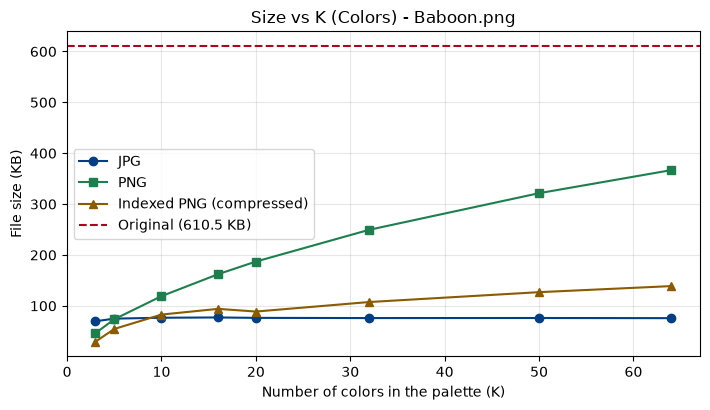

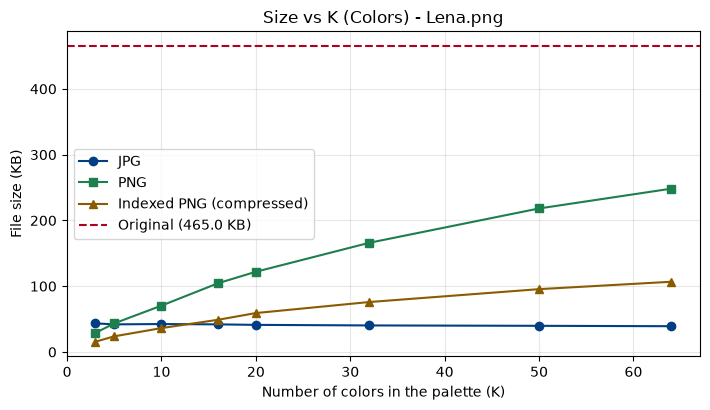

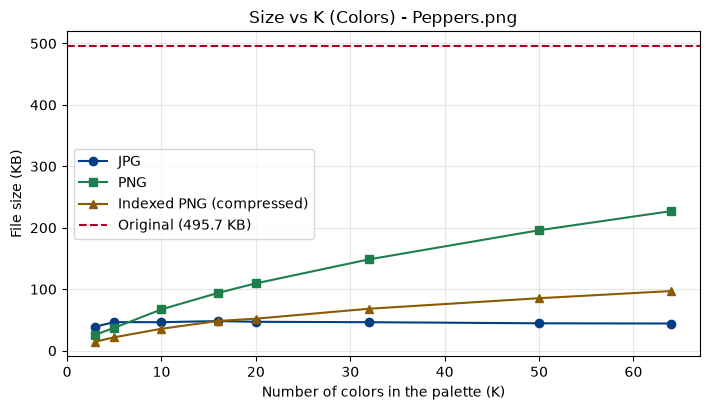

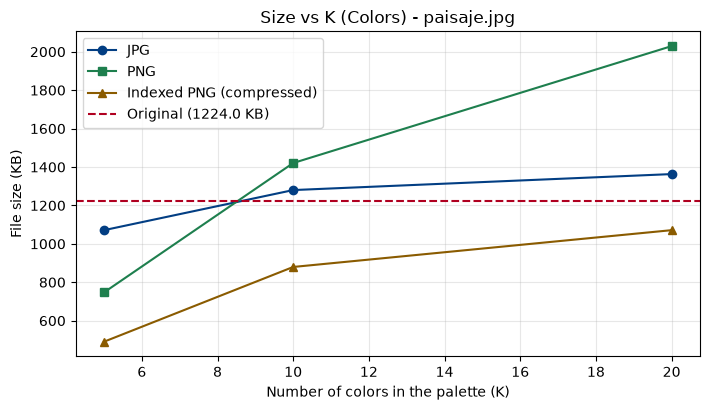

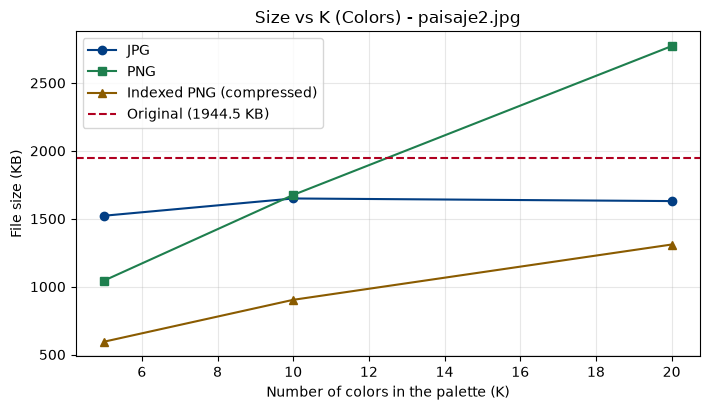

In [38]:
# TODO (c) For each image, plot size in KB against K with one curve per format
#          (jpg, png, indexed png), and mark the size of the original file.

import os
import matplotlib.pyplot as plt

image_config = {
    "Baboon.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "Lena.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "Peppers.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "paisaje.jpg": [5, 10, 20],
    "paisaje2.jpg": [5, 10, 20]
}

for img_name, k_values in image_config.items():
    base_name = img_name.split('.')[0]
    
    original_path = f"../Files_clustering/images/{img_name}"
    original_size = get_size(original_path)
    
    jpg_sizes = []
    png_sizes = []
    compressed_sizes = []
    
    for k in k_values:
        reduced_base_path = f"../reduced_images/{base_name}_{k}"
        
        jpg_sizes.append(get_size(reduced_base_path + ".jpg"))
        png_sizes.append(get_size(reduced_base_path + ".png"))
        compressed_sizes.append(get_size(reduced_base_path + "compressed.png"))
        
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    
    ax.plot(k_values, jpg_sizes, marker='o', color='#023E83', label='JPG')
    ax.plot(k_values, png_sizes, marker='s', color='#1E7F4E', label='PNG')
    ax.plot(
        k_values,
        compressed_sizes,
        marker='^',
        color='#8A5B00',
        label='Indexed PNG (compressed)'
    )
    
    ax.axhline(
        y=original_size,
        color='#B00020',
        linestyle='--',
        linewidth=1.5,
        label=f'Original ({original_size:.1f} KB)'
    )
    
    ax.set_title(f"Size vs K (Colors) - {img_name}")
    ax.set_xlabel("Number of colors in the palette (K)")
    ax.set_ylabel("File size (KB)")
    ax.grid(alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

### 4(d) — Interpretation

**TODO.** Answer all four questions from the statement:

Which format shrinks as $K$ decreases, and which barely responds at all — explained by how each format encodes an image.

The format that reduces its size dramatically as $K$ decreases is PNG (represented by the green standard PNG line and the brown indexed PNG line). This behavior is evident in all the graphs; for example, in paisaje.jpg, standard PNG drops from more than 2000 KB at $K=20$ to approximately 750 KB at $K=5$. In contrast, JPG (blue line) is the format that barely responds to changes in the color palette. In the graphs for Baboon.png, Lena.png, and Peppers.png, the JPG line remains practically horizontal across the entire x-axis. This is because PNG compresses by grouping repeated exact colors, benefiting from reduced palettes, whereas JPG does not use palettes but instead processes the overall visual frequencies of the image.

Why the JPG at small $K$ can be **larger** than at a much larger $K$.

The graphs empirically show that the JPG file size at a low $K$ can exceed its size at a high $K$. In the Baboon.png graph, the blue JPG line has a slight peak around $K=16$ (reaching nearly 80 KB), then decreases and stabilizes below that level at $K=64$. In Lena.png, the JPG at $K=5$ or $K=10$ is slightly larger than at $K=64$. Since JPG is optimized for smooth gradients, reducing the image to 5 or 16 colors creates hard edges and artificial jumps between pixels that the algorithm interprets as complex information to compress, resulting in larger files.

What property of the content makes Baboon.png behave differently from Lena.png.

The differentiating property (texture and high-frequency detail) is clearly reflected when comparing the evolution of the PNG file sizes for both images. Although the original files have comparable sizes (610.5 KB for Baboon and 465.0 KB for Lena), their PNG versions scale at very different rates. At $K=64$, the PNG version of Baboon reaches around 370 KB, while Lena only reaches around 250 KB. The chaotic texture of the baboon's fur prevents PNG from finding long repetitive sequences to compress, unlike the smooth gradients present in Lena's image.

Looking at the images: at roughly which $K$ does each stop looking obviously damaged, and does that agree with where the size curve flattens?

The point at which the file size stops increasing aggressively coincides with the point at which the images should stop looking noticeably degraded. In the graphs for Baboon.png, Lena.png, and Peppers.png, the Indexed PNG curve (brown) shows a change in slope (an "elbow") and flattens significantly from values between $K=16$ and $K=32$ onwards. In the graphs for paisaje.jpg and paisaje2.jpg, the section of the indexed curve between $K=10$ and $K=20$ already shows a less steep slope than the abrupt jump between $K=5$ and $K=10$. This flattening indicates that, from these $K$ values onwards, adding new colors to the palette barely increases the complexity of the file because the main visual structure is already well defined and stabilized.

